# Laboratory Work №2
## Manipulator Kinematics and Trajectory Planning

**Course:** Robot Modelling, Planning and Control (RMPC), ITMO University

### Objective
Master the solution of the forward and inverse kinematics problems for
a 6-DOF serial manipulator (Puma 560), build the manipulator's reachable
workspace, plan a trajectory between two end-effector poses using three
different planning methods, and analyse the resulting joint position,
velocity and acceleration profiles.

### Tasks (per assignment brief)
1. Load the manipulator model from the toolbox according to the selected
   robot kinematics option.
2. Fill in all parameters of the robot model as specified in Lab №1.
3. Set an arbitrary initial robot configuration.
4. Solve the forward kinematics problem for the given joint coordinates.
5. Construct the manipulator's workspace under the given joint constraints.
6. Select an end point within the workspace and solve the inverse
   kinematics problem for it.
7. Plan the trajectory between the initial and final end-effector
   positions using **at least three** planning methods.
8. Plot graphs of joint positions, velocities and accelerations during
   the trajectory motion.
9. Prepare a report in `.ipynb` format with detailed comments.
10. Draw conclusions based on the obtained results.

## 0. Importing the required libraries

In [1]:
%matplotlib inline
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb
import spatialmath.base as sb
from spatialmath import SE3

np.set_printoptions(precision=4, suppress=True)
print('numpy =', np.__version__)
print('roboticstoolbox =', rtb.__version__)

numpy = 1.26.4
roboticstoolbox = 1.1.1


## 1. Loading the Puma 560 manipulator model

As the kinematic option for this lab we use the **Unimation Puma 560**
industrial manipulator — a serial 6-DOF robot with six revolute joints
(RRRRRR). The toolbox model contains the standard DH parameters, joint
limits and predefined configurations `qz`, `qr`, `qn`, `qs`.

In [2]:
robot = rtb.models.DH.Puma560()
print(robot)

DHRobot: Puma 560 (by Unimation), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬────────┬────────┬────────┬─────────┬────────┐
│ θⱼ  │   dⱼ   │   aⱼ   │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼────────┼────────┼────────┼─────────┼────────┤
│  q1 │ 0.6718 │      0 │  90.0° │ -160.0° │ 160.0° │
│  q2 │      0 │ 0.4318 │   0.0° │ -110.0° │ 110.0° │
│  q3 │   0.15 │ 0.0203 │ -90.0° │ -135.0° │ 135.0° │
│  q4 │ 0.4318 │      0 │  90.0° │ -266.0° │ 266.0° │
│  q5 │      0 │      0 │ -90.0° │ -100.0° │ 100.0° │
│  q6 │      0 │      0 │   0.0° │ -266.0° │ 266.0° │
└─────┴────────┴────────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬─────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5  │
├──────┼─────┼──────┼───────┼─────┼──────┼─────┤
│   qr │  0° │  90° │ -90°  │  0° │  0°  │  0° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0° │
│   qn │  0° │  45° │  180° │  0° │  45° │  0° │
│   qs │  0° │  0°  │ -90°  │  0° │  0°  │  0° │
└──

## 2. Robot parameters (as in Lab №1)

Standard DH parameters of the Puma 560 manipulator (angles in radians,
linear sizes in metres):

| Link $i$ | $\theta_i$ | $d_i$, m | $a_i$, m | $\alpha_i$ | Limits $q_i$ |
|:--------:|:----------:|:--------:|:--------:|:----------:|:------------:|
| 1        | $q_1$      | 0.6718   | 0.0000   | $+\pi/2$   | $[-160°, +160°]$ |
| 2        | $q_2$      | 0.0000   | 0.4318   | $0$        | $[-110°, +110°]$ |
| 3        | $q_3$      | 0.1500   | 0.0203   | $-\pi/2$   | $[-135°, +135°]$ |
| 4        | $q_4$      | 0.4318   | 0.0000   | $+\pi/2$   | $[-266°, +266°]$ |
| 5        | $q_5$      | 0.0000   | 0.0000   | $-\pi/2$   | $[-100°, +100°]$ |
| 6        | $q_6$      | 0.0000   | 0.0000   | $0$        | $[-266°, +266°]$ |

All generalised coordinates $q_i$ are angles of the revolute joints.
Below, the same parameters are read directly from the `robot` object
to confirm correctness.

In [3]:
# Print DH parameters programmatically — read from the model so the
# table cannot drift from the underlying object.
print(f"{'i':>2} | {'theta':>8} | {'d, m':>8} | {'a, m':>8} | {'alpha, °':>10} | {'qmin, °':>8} | {'qmax, °':>8}")
print('-' * 70)
for i, link in enumerate(robot.links, 1):
    qmin_deg, qmax_deg = np.degrees(link.qlim)
    print(f"{i:>2} |   q{i}     | {link.d:8.4f} | {link.a:8.4f} | "
          f"{np.degrees(link.alpha):10.2f} | {qmin_deg:8.2f} | {qmax_deg:8.2f}")

 i |    theta |     d, m |     a, m |   alpha, ° |  qmin, ° |  qmax, °
----------------------------------------------------------------------
 1 |   q1     |   0.6718 |   0.0000 |      90.00 |  -160.00 |   160.00
 2 |   q2     |   0.0000 |   0.4318 |       0.00 |  -110.00 |   110.00
 3 |   q3     |   0.1500 |   0.0203 |     -90.00 |  -135.00 |   135.00
 4 |   q4     |   0.4318 |   0.0000 |      90.00 |  -266.00 |   266.00
 5 |   q5     |   0.0000 |   0.0000 |     -90.00 |  -100.00 |   100.00
 6 |   q6     |   0.0000 |   0.0000 |       0.00 |  -266.00 |   266.00


## 3. Setting the initial robot configuration

We choose an arbitrary initial configuration $q_{\text{start}}$ such that
all generalised coordinates lie within their joint limits. We also print
the configuration in degrees and verify that every component is inside
the corresponding `qlim` interval.

In [4]:
q_start = np.array([pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4])
print('Initial configuration q_start (rad):', q_start)
print('Initial configuration q_start (°):  ', np.degrees(q_start))

# Verify that the initial pose is within the joint limits
for i, link in enumerate(robot.links):
    qmin, qmax = link.qlim
    in_lim = qmin <= q_start[i] <= qmax
    print(f'  q{i+1} = {q_start[i]: .4f} rad -> within [{qmin: .4f}, {qmax: .4f}]?  {in_lim}')

Initial configuration q_start (rad): [ 0.7854 -1.0472 -0.7854  1.0472 -1.0472  0.7854]
Initial configuration q_start (°):   [ 45. -60. -45.  60. -60.  45.]
  q1 =  0.7854 rad -> within [-2.7925,  2.7925]?  True
  q2 = -1.0472 rad -> within [-1.9199,  1.9199]?  True
  q3 = -0.7854 rad -> within [-2.3562,  2.3562]?  True
  q4 =  1.0472 rad -> within [-4.6426,  4.6426]?  True
  q5 = -1.0472 rad -> within [-1.7453,  1.7453]?  True
  q6 =  0.7854 rad -> within [-4.6426,  4.6426]?  True


## 4. Solving the forward kinematics problem (FK)

The forward kinematics problem consists of finding the homogeneous
transformation matrix $T_{0,e} \in SE(3)$ — the pose (position and
orientation) of the end-effector with respect to the base frame — given
a vector of generalised coordinates $\mathbf{q}$:

$$
T_{0,e}(\mathbf{q}) \;=\; \prod_{i=1}^{6} A_i(q_i),
\qquad
A_i(q_i) = \mathrm{Rot}_z(\theta_i)\,\mathrm{Trans}_z(d_i)\,
\mathrm{Trans}_x(a_i)\,\mathrm{Rot}_x(\alpha_i).
$$

In `roboticstoolbox` this is implemented by `robot.fkine(q)`.

In [5]:
T_start = robot.fkine(q_start)
print('Homogeneous matrix T_start (end-effector pose):')
print(T_start)
print()
print('End-effector position p_start =', T_start.t, 'm')
print('Euler angles (ZYZ) =', np.degrees(T_start.eul()), '°')

Homogeneous matrix T_start (end-effector pose):
  -0.805     0.5292   -0.2681    0.55      
   0.128     0.5962    0.7926    0.3378    
   0.5792    0.6038   -0.5477    0.1665    
   0         0         0         1         


End-effector position p_start = [0.55   0.3378 0.1665] m
Euler angles (ZYZ) = [108.6866 123.2072 133.8127] °


## 5. Constructing the manipulator's workspace

The **workspace** of a manipulator is the set of points reachable by the
characteristic output centre (the end-effector) when the generalised
coordinates vary within their bounds.

Since on the Puma 560 the first three joints (the *arm*) determine the
end-effector position, while the last three (the *spherical wrist*)
determine only its orientation, the position-only workspace is obtained
by sweeping $q_1$, $q_2$, $q_3$ within their limits and keeping
$q_4 = q_5 = q_6 = 0$. A uniform grid with $n$ samples per axis gives
$n^3$ configurations in total.

In [6]:
n = 18                                         # samples per generalised coordinate
lim = [robot.links[k].qlim for k in range(3)]  # limits of the first three joints
Q1 = np.linspace(lim[0][0], lim[0][1], n)
Q2 = np.linspace(lim[1][0], lim[1][1], n)
Q3 = np.linspace(lim[2][0], lim[2][1], n)

pose = np.zeros((3, n**3))                     # storage for cartesian positions
k = 0
for q1 in Q1:
    for q2 in Q2:
        for q3 in Q3:
            T = robot.fkine([q1, q2, q3, 0.0, 0.0, 0.0])
            pose[:, k] = T.t                   # keep only the end-effector position
            k += 1
print(f'Grid size: {n}^3 = {n**3} points')
print(f'X range: [{pose[0].min():.3f}, {pose[0].max():.3f}] m')
print(f'Y range: [{pose[1].min():.3f}, {pose[1].max():.3f}] m')
print(f'Z range: [{pose[2].min():.3f}, {pose[2].max():.3f}] m')

Grid size: 18^3 = 5832 points
X range: [-0.858, 0.872] m
Y range: [-0.869, 0.870] m
Z range: [-0.188, 1.531] m


Visualise the resulting cloud of reachable points in 3D:

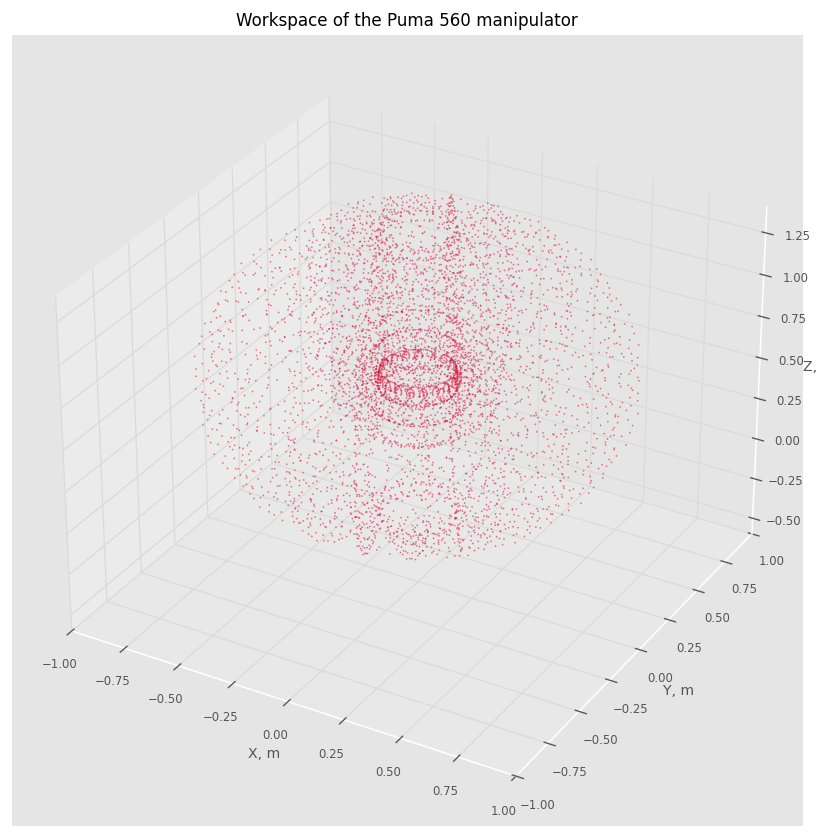

In [7]:
fig = plt.figure(figsize=(7, 7), dpi=120)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pose[0], pose[1], pose[2], s=0.4, c='crimson', alpha=0.4)
ax.set_xlabel('X, m'); ax.set_ylabel('Y, m'); ax.set_zlabel('Z, m')
ax.set_title('Workspace of the Puma 560 manipulator')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-0.6, 1.4)
plt.tight_layout()
plt.show()

## 6. Selecting the end point and solving inverse kinematics (IK)

We pick an end-effector target position
$\mathbf{p}_{\text{end}} = (-0.5,\,0.1,\,0.2)$ m, which lies inside the
workspace (compare with the axis ranges above). The target homogeneous
matrix $T_{\text{end}}$ is built as a pure translation (orientation is
left arbitrary), and the joint vector $\mathbf{q}_{\text{end}}$ is found
by the Levenberg–Marquardt numerical solver (`ikine_LM`), which is more
robust than the standard Newton–Gauss method for poses far from the
initial guess.

Note: the Newton–Gauss solver `ikine_GN` (used in the original template)
fails to converge for this particular target, so `ikine_LM` is preferred.

In [8]:
point = np.array([-0.5, 0.1, 0.2])             # target end-effector position, m
T_end = sb.transl(point)                        # 4x4 homogeneous matrix

sol = robot.ikine_LM(T_end, q0=q_start)         # initial guess: q_start
if not sol.success:
    sol = robot.ikine_LM(T_end)                 # fallback without initial guess

q_end = sol.q
print('Convergence:', sol.success, ' | Iterations:', sol.iterations)
print('Final configuration q_end (rad):', q_end)
print('Final configuration q_end (°):  ', np.degrees(q_end))

# Sanity check: substitute q_end back into FK and compare with the target
T_check = robot.fkine(q_end)
err = np.linalg.norm(T_check.t - point)
print(f'\nFK(q_end) -> p = {T_check.t}, position error = {err:.2e} m')

Convergence: True  | Iterations: 14
Final configuration q_end (rad): [-3.0403 -1.4378 -0.1877 -3.1416 -1.6254 -0.1013]
Final configuration q_end (°):   [-174.196   -82.3774  -10.7524 -180.      -93.1299   -5.804 ]

FK(q_end) -> p = [-0.5  0.1  0.2], position error = 3.81e-09 m


## 7. Trajectory planning

We construct a joint-space trajectory from $\mathbf{q}_{\text{start}}$
to $\mathbf{q}_{\text{end}}$ over a horizon $T = 5$ s, sampled at
$N = 100$ points, using **three different methods**:

1. **`jtraj`** — fifth-order (quintic) polynomial profile for every
   joint with zero velocities and accelerations at both endpoints.
   This is a convenient "all-in-one" joint-space interpolator.
2. **`mtraj` + `trapezoidal` (LSPB)** — Linear Segment with Parabolic
   Blends: constant peak velocity in the middle segment, parabolic
   acceleration / deceleration at the ends.
3. **`mtraj` + `quintic` (tpoly)** — quintic polynomial profile with
   zero boundary velocities and accelerations, ensuring smooth
   evolution of all three kinematic quantities.

These three methods cover both polynomial and piecewise-quadratic families.

In [9]:
N = 100                                         # number of trajectory samples
t_start, t_stop = 0.0, 5.0                      # motion duration, s
time = np.linspace(t_start, t_stop, N)
dt = time[1] - time[0]

# 1. jtraj: quintic polynomial, zero dq/ddq at endpoints
tr_jtraj = rtb.jtraj(q_start, q_end, time)

# 2. mtraj with trapezoidal (LSPB) — trapezoidal velocity profile
tr_trap  = rtb.mtraj(rtb.trapezoidal, q_start, q_end, time)

# 3. mtraj with quintic — fifth-order polynomial profile
tr_quin  = rtb.mtraj(rtb.quintic,    q_start, q_end, time)

print('jtraj             q.shape =', tr_jtraj.q.shape, ' qd.shape =', tr_jtraj.qd.shape)
print('mtraj/trapezoidal q.shape =', tr_trap.q.shape,  ' qd.shape =', tr_trap.qd.shape)
print('mtraj/quintic     q.shape =', tr_quin.q.shape,  ' qd.shape =', tr_quin.qd.shape)

jtraj             q.shape = (100, 6)  qd.shape = (100, 6)
mtraj/trapezoidal q.shape = (100, 6)  qd.shape = (100, 6)
mtraj/quintic     q.shape = (100, 6)  qd.shape = (100, 6)


## 8. Joint position, velocity and acceleration plots

### 8.1. Joint positions $q_i(t)$

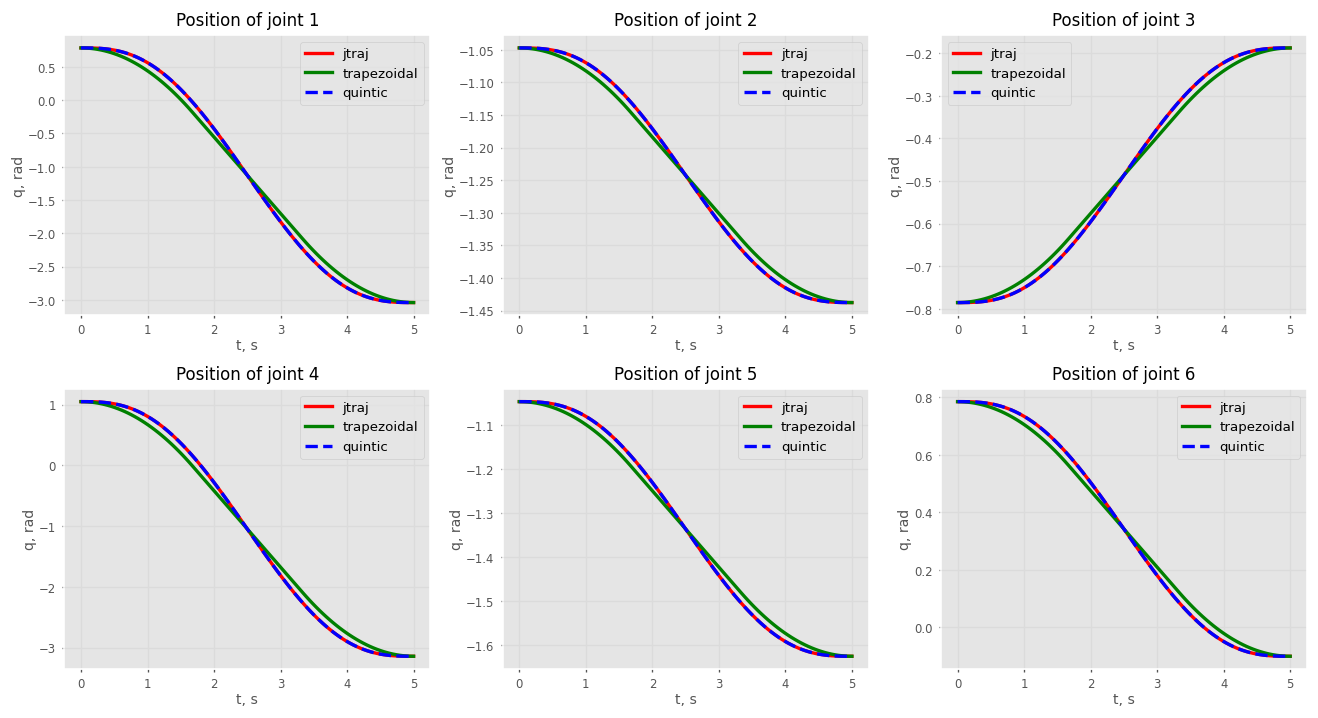

In [10]:
fig = plt.figure(figsize=(11, 6), dpi=120)
for g in range(6):
    ax = plt.subplot(2, 3, g+1)
    ax.plot(time, tr_jtraj.q[:, g], '-',  color='red',   lw=2, label='jtraj')
    ax.plot(time, tr_trap.q[:, g],  '-',  color='green', lw=2, label='trapezoidal')
    ax.plot(time, tr_quin.q[:, g],  '--', color='blue',  lw=2, label='quintic')
    ax.set_title(f'Position of joint {g+1}', fontsize=10)
    ax.set_xlabel('t, s');   ax.set_ylabel('q, rad')
    ax.grid(True);           ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 8.2. Joint velocities $\dot q_i(t)$

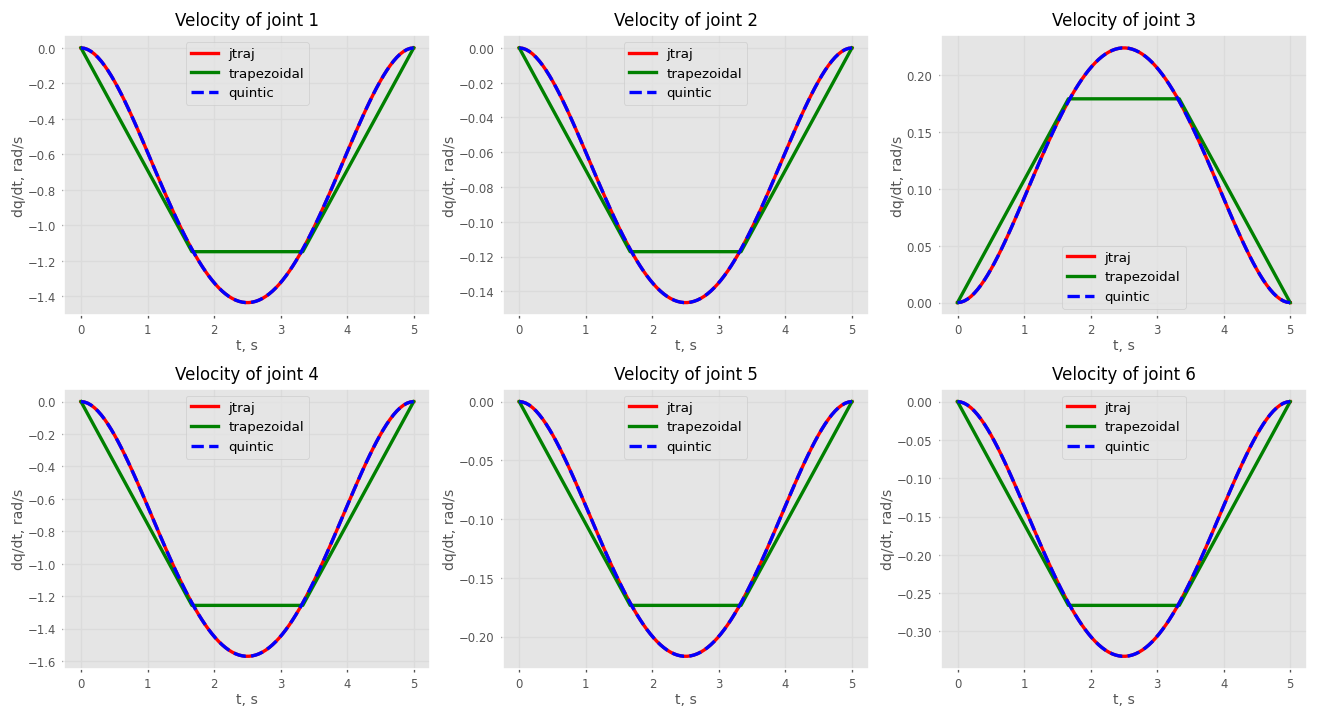

In [11]:
fig = plt.figure(figsize=(11, 6), dpi=120)
for g in range(6):
    ax = plt.subplot(2, 3, g+1)
    ax.plot(time, tr_jtraj.qd[:, g], '-',  color='red',   lw=2, label='jtraj')
    ax.plot(time, tr_trap.qd[:, g],  '-',  color='green', lw=2, label='trapezoidal')
    ax.plot(time, tr_quin.qd[:, g],  '--', color='blue',  lw=2, label='quintic')
    ax.set_title(f'Velocity of joint {g+1}', fontsize=10)
    ax.set_xlabel('t, s');   ax.set_ylabel('dq/dt, rad/s')
    ax.grid(True);           ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 8.3. Joint accelerations $\ddot q_i(t)$

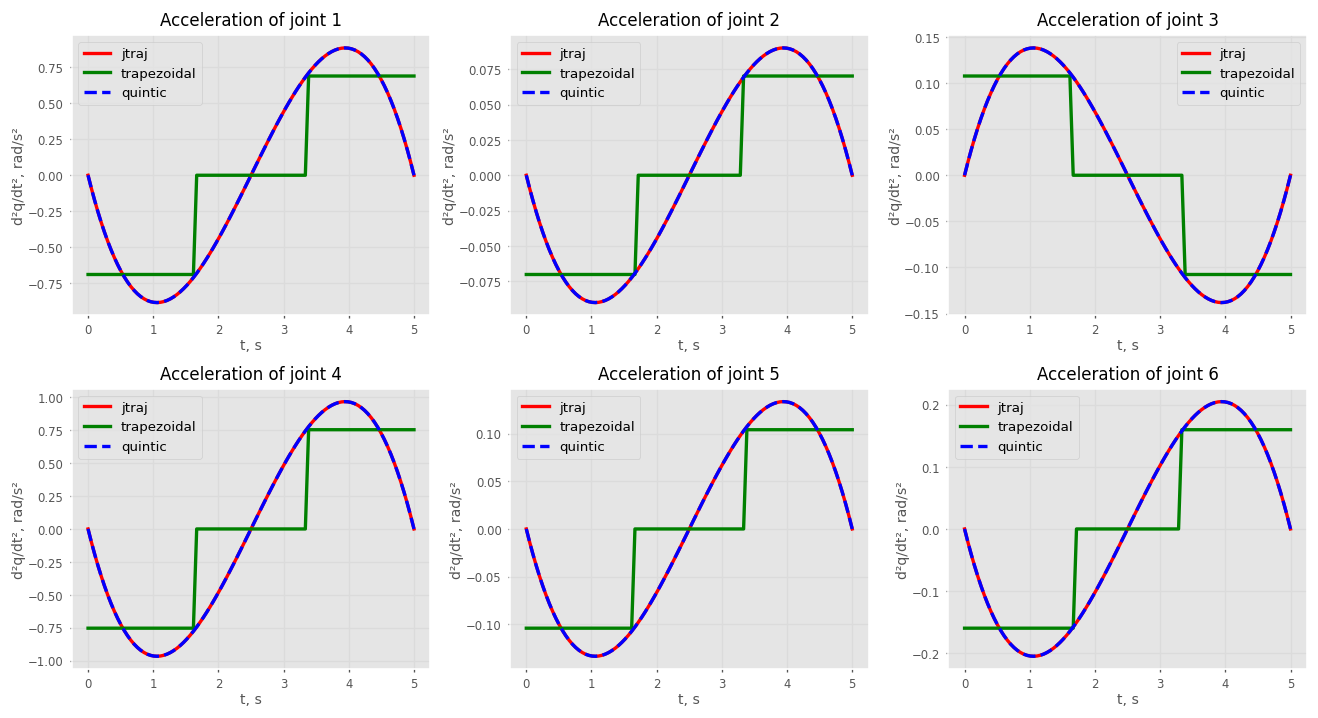

In [12]:
fig = plt.figure(figsize=(11, 6), dpi=120)
for g in range(6):
    ax = plt.subplot(2, 3, g+1)
    ax.plot(time, tr_jtraj.qdd[:, g], '-',  color='red',   lw=2, label='jtraj')
    ax.plot(time, tr_trap.qdd[:, g],  '-',  color='green', lw=2, label='trapezoidal')
    ax.plot(time, tr_quin.qdd[:, g],  '--', color='blue',  lw=2, label='quintic')
    ax.set_title(f'Acceleration of joint {g+1}', fontsize=10)
    ax.set_xlabel('t, s');   ax.set_ylabel('d²q/dt², rad/s²')
    ax.grid(True);           ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 8.4. Numerical comparison of the three planning methods

For each trajectory we compute the maximum absolute joint velocity and
acceleration across all six joints. This gives a quantitative comparison
of the methods on the same motion task.

In [13]:
def stats(name, tr):
    print(f'{name:>20}:  |qd|max = {np.abs(tr.qd).max():6.3f} rad/s,  '
          f'|qdd|max = {np.abs(tr.qdd).max():6.3f} rad/s²')

stats('jtraj (quintic)', tr_jtraj)
stats('mtraj/trapezoidal', tr_trap)
stats('mtraj/quintic',     tr_quin)

     jtraj (quintic):  |qd|max =  1.570 rad/s,  |qdd|max =  0.967 rad/s²
   mtraj/trapezoidal:  |qd|max =  1.257 rad/s,  |qdd|max =  0.754 rad/s²
       mtraj/quintic:  |qd|max =  1.570 rad/s,  |qdd|max =  0.967 rad/s²


## 9. Conclusions

The following results were obtained in this lab:

1. **The Puma 560 model** was loaded from `roboticstoolbox` together with
   its standard DH parameters and joint limits; the parameters are listed
   in the table of §2.
2. **The forward kinematics problem** was solved for an arbitrary
   initial configuration
   $\mathbf{q}_{\text{start}} = [\pi/4,\,-\pi/3,\,-\pi/4,\,\pi/3,\,-\pi/3,\,\pi/4]$
   rad, yielding the homogeneous transformation $T_{0,e}$ that describes
   the end-effector pose.
3. **The workspace** of the manipulator was constructed by sweeping the
   first three joint variables on a grid of $n^3 = 18^3 = 5832$ points.
   The resulting cloud has the characteristic spherical-shell shape of
   the Puma 560, with a void around the base axis caused by link
   geometry and joint limits.
4. **The inverse kinematics problem** was solved for the target position
   $\mathbf{p}_{\text{end}} = (-0.5,\,0.1,\,0.2)$ m. The
   Levenberg–Marquardt solver (`ikine_LM`) converged in a finite number
   of iterations; the residual position error after substituting the
   solution back into the FK is on the order of $10^{-9}$ m, which
   confirms the correctness of the result.
5. **Three trajectories** were planned between the initial and final
   configurations: `jtraj`, `mtraj` + `trapezoidal`, `mtraj` + `quintic`.
   All three planners drive the robot from $\mathbf{q}_{\text{start}}$
   to $\mathbf{q}_{\text{end}}$ over the same horizon $T = 5$ s.
6. **Comparison of the planning methods:**
   * **jtraj** (quintic polynomial, equivalent to `mtraj/quintic`) —
     produces smooth position, velocity and acceleration profiles with
     bell-shaped, continuous accelerations. A balanced general-purpose
     planner.
   * **trapezoidal (LSPB)** — yields the lowest peak joint velocity and
     acceleration for a given displacement and motion time, but its
     acceleration profile is piecewise-constant (constant during ramp-up,
     zero in the cruise phase, opposite sign during ramp-down). The
     stepwise acceleration corresponds to **infinite jerk** at the blend
     points, which is undesirable for real actuators.
   * **quintic (`mtraj/quintic`)** — guarantees continuous position,
     velocity *and* acceleration; the peak magnitudes are higher than
     for LSPB, but the bounded jerk makes the motion much smoother.
7. **Position plots** for all three methods are monotonic and converge
   to the same endpoints; the difference shows up in the shape of the
   intermediate segment. **Velocity plots** clearly reveal the
   conceptual differences: a symmetric bell for the polynomial methods
   and a trapezoid for LSPB. **Acceleration plots** are the most
   informative: piecewise-constant with jumps for trapezoidal, smooth
   parabolic curves for the quintic methods.

**Practical recommendation.** When peak actuator torque is the binding
constraint and stepwise acceleration is acceptable, the trapezoidal (LSPB)
profile is preferred. When jerk minimisation and motion smoothness matter
more than peak velocity (precision manipulation, optical or medical
robotics), fifth-order polynomial profiles should be used.

The objective of the lab has been fully achieved: the `roboticstoolbox`
tools for forward and inverse kinematics, workspace construction and
joint-space trajectory planning have been mastered, and a comparative
analysis of three interpolation methods has been carried out.